# So sánh kiến trúc (theo từng part)

Đọc kết quả đã test trong `runs/<RUN_NAME>/` (không train/test lại), ra bảng và biểu đồ:
mean ± std qua seed, theo generator, theo ô 2×2, theo nhánh P2, định vị thời gian, paired ΔAUC có CI và chi phí.

| | |
|---|---|
| **Theo part** | Mỗi part một bộ bảng riêng (`PARTS = "each"`); có >1 part thì thêm bảng gộp. Kết luận chính đọc trên **test** |
| **Chạy ở** | Local (`notebooks/`, dùng env `vn-av-df`) hoặc Kaggle (attach Output train). Chỉ cần numpy, scikit-learn, matplotlib |
| **Đầu ra** | `reports/compare/<split>_<part>.md` + ảnh PNG; bảng cũng hiện ngay trong notebook |

> Khoảng tin cậy bootstrap theo **clip gốc** (cả real/fake/sham của một clip đi cùng nhau). Khi test chỉ có vài speaker,
> CI này **lạc quan** vì bỏ qua tương quan giữa các clip cùng người; notebook in số speaker để đọc kèm.

## 1. Thư viện và đường dẫn
- **Chạy ở local (VS Code/Jupyter):** chọn kernel env `vn-av-df`. Lần đầu báo thiếu `ipykernel` thì cài một lần trong Anaconda Prompt:
  `conda activate vn-av-df` rồi `python -m pip install ipykernel` (không dùng lệnh conda VS Code gợi ý có `--update-deps --force-reinstall`, dễ đổi torch/numpy).
- Trên Kaggle đã có sẵn, không cần cài.

In [1]:
from pathlib import Path
import json, math
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
try:
    from IPython.display import Markdown, display
except ImportError:  # Chạy ngoài Jupyter (python thường): in bảng dạng text.
    Markdown, display = str, print

# Chạy từ notebooks/ hoặc gốc repo ở local; trên Kaggle sửa đường dẫn ở mục 2.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

## 2. Chọn run, part và cặp so sánh
- `RUNS`: một hoặc nhiều thư mục run **cùng dữ liệu** (cùng hash manifest); một kiến trúc/seed chỉ được ở một run.
- `PART_MANIFESTS`: manifest các part, để lấy clip gốc/speaker cho bootstrap khi predictions cũ chưa ghi hai trường này.
- `PARTS = "each"`: bảng riêng cho từng part (+ gộp); hoặc danh sách tên part.
- `SPLIT = "validation"` chỉ để xem; validation đã dùng chọn checkpoint/ngưỡng nên không dùng để kết luận.

In [2]:
RUNS = [ROOT / "runs/train_part1_run01"]
PART_MANIFESTS = [ROOT / "datasets/vn-av-df-data/vn-av-df-data-part1/manifest.jsonl"]
PARTS = "each"
SPLIT = "test"
NAMES = {  # Thứ tự hiển thị và tên trong báo cáo.
    "fate_gru": "B-FATE", "avh_tcn": "B-AVH", "avh_realrecon": "AVH-realrecon",
    "p2_syncartifact": "P2", "p2_concat": "P2-concat", "p2_sync_seen_fake": "P2-sync-seen-fake",
    "p2_sync_only": "P2-sync-only", "p2_artifact_only": "P2-artifact-only",
}
PAIRS = [  # Paired ΔAUC (A − B) trên cùng mẫu.
    ("p2_syncartifact", "avh_tcn"), ("p2_syncartifact", "fate_gru"), ("avh_tcn", "fate_gru"),
    ("p2_syncartifact", "p2_artifact_only"), ("p2_syncartifact", "p2_concat"),
    ("p2_syncartifact", "p2_sync_seen_fake"), ("p2_sync_only", "avh_tcn"), ("avh_realrecon", "avh_tcn"),
]
BOOTSTRAP = 2000
CACHES = [ROOT / "cache/vn-av-df-data"]  # extraction.json cho bảng chi phí (tuỳ chọn).
GENERATED = [ROOT / "datasets/vn-av-df-data/vn-av-df-data-part1"]  # generation.json (tuỳ chọn).
OUTPUT = ROOT / "reports/compare"

## 3. Nạp kết quả
Kiểm cùng dữ liệu, cùng tập mẫu giữa các model; in số speaker/clip gốc theo part.

In [3]:
def read(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

models, selection = {}, None  # (kiến trúc, seed) -> metrics, predictions, resources
for run in map(Path, RUNS):
    index = read(run / "training.json")
    if selection is None:
        selection = index["dataset_selection"]
    elif index["dataset_selection"]["manifest_sha256"] != selection["manifest_sha256"]:
        raise ValueError(f"{run} dùng dữ liệu khác run đầu; không so sánh trực tiếp được")
    for entry in index["runs"]:
        key = (entry["architecture"], entry["seed"])
        folder = run / f"{key[0]}_seed{key[1]}"
        if key in models:
            raise ValueError(f"{key} có ở nhiều run")
        if not (folder / f"predictions-{SPLIT}.json").exists():
            print("Bỏ qua (chưa có", SPLIT + "):", folder)
            continue
        models[key] = {
            "metrics": read(folder / f"{SPLIT}.json"),
            "preds": {p["sample_id"]: p for p in read(folder / f"predictions-{SPLIT}.json")},
            "resources": read(folder / "resources.json"),
        }
archs = [a for a in NAMES if any(k[0] == a for k in models)] + sorted({a for a, _ in models} - set(NAMES))
seeds = sorted({s for _, s in models})
ids = sorted(next(iter(models.values()))["preds"])
assert all(set(m["preds"]) == set(ids) for m in models.values()), "Các model không cùng tập mẫu"

meta = {}  # Trường thiếu trong predictions cũ lấy từ manifest part.
for path in PART_MANIFESTS:
    if Path(path).exists():
        for line in Path(path).read_text(encoding="utf-8").splitlines():
            if line.strip():
                row = json.loads(line)
                meta[row["sample_id"]] = row
first = next(iter(models.values()))["preds"]

def field(sid, key, default="-"):
    value = first[sid].get(key)
    return value if value is not None else meta.get(sid, {}).get(key, default)

labels = np.array([first[s]["label"] for s in ids])
conds = np.array([first[s]["condition"] for s in ids])
part_of = np.array([first[s].get("dataset_part") or "-" for s in ids])
parents = np.array([field(s, "source_clip_id", s) for s in ids])
speakers = np.array([field(s, "speaker_id") for s in ids])
gens = np.array([c.split("/")[0] if "/" in c else "-" for c in conds])
names = sorted(set(part_of))
groups = {f"{p}": part_of == p for p in names} if PARTS == "each" else {p: part_of == p for p in PARTS}
if PARTS == "each" and len(names) > 1:
    groups["gộp các part"] = np.ones(len(ids), bool)
print(f"{len(models)} model ({len(archs)} kiến trúc × seed {seeds}), {SPLIT}: {len(ids)} mẫu")
for name, mask in groups.items():
    print(f"  {name}: {mask.sum()} mẫu, {len(set(parents[mask]))} clip gốc, "
          f"{len(set(speakers[mask]))} speaker {sorted(set(speakers[mask]))}")

24 model (8 kiến trúc × seed [42, 43, 44]), test: 820 mẫu
  vn-av-df-data-part1: 820 mẫu, 82 clip gốc, 2 speaker [np.str_('speaker_01'), np.str_('speaker_08')]


## 4. Hàm tính chỉ số
AUC không cần ngưỡng; F1/false alarm dùng ngưỡng video đã khóa trên validation (`thresholds` trong `test.json`).

In [4]:
def scores(arch, seed, branch=None):
    """Điểm video; nhánh P2 = mean top-k ô hợp lệ như lúc đánh giá."""
    preds, out = models[(arch, seed)]["preds"], []
    top = (models[(arch, seed)]["metrics"].get("branches") or {}).get("top_fraction", 0.1)
    for sid in ids:
        p = preds[sid]
        if branch is None:
            out.append(np.nan if p["video_score"] is None else p["video_score"])
            continue
        values = np.array(p["branch_scores"][branch])[np.array(p["valid"], bool)]
        out.append(np.sort(values)[-max(1, math.ceil(len(values) * top)):].mean() if len(values) else np.nan)
    return np.array(out, float)

def auc(mask, x):
    sel = mask & np.isfinite(x)
    return roc_auc_score(labels[sel], x[sel]) if len(set(labels[sel])) == 2 else None

def cell_auc(mask, cell, x):
    """Ô 2×2 (kể cả sham) so với real gốc: positive = thuộc ô, không theo nhãn AI."""
    sel = mask & ((conds == "real") | (conds == cell)) & np.isfinite(x)
    y = conds[sel] == cell
    return roc_auc_score(y, x[sel]) if len(set(y)) == 2 else None

def at_threshold(arch, seed, mask):
    x, thr = scores(arch, seed), models[(arch, seed)]["metrics"]["thresholds"]["video"]
    sel = mask & np.isfinite(x)
    y, hit = labels[sel], x[sel] >= thr
    tp, fp, fn = int((hit & (y == 1)).sum()), int((hit & (y == 0)).sum()), int((~hit & (y == 1)).sum())
    negatives = int((y == 0).sum())
    return {"f1": 2 * tp / (2 * tp + fp + fn) if tp else 0.0, "far": fp / negatives if negatives else None}

def ms(values, digits=3):
    values = [v for v in values if v is not None and np.isfinite(v)]
    if not values:
        return "-"
    if len(values) == 1:
        return f"{values[0]:.{digits}f}"
    return f"{np.mean(values):.{digits}f} ± {np.std(values, ddof=1):.{digits}f}"

def table(header, rows):
    return "\n".join(["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
                     + ["| " + " | ".join(map(str, r)) + " |" for r in rows])

def label(arch):
    return NAMES.get(arch, arch)

def ensemble(arch):
    return np.nanmean([scores(arch, s) for s in seeds if (arch, s) in models], axis=0)

def paired_delta(a, b, mask, rng):
    """ΔAUC seed-ensemble A − B, bootstrap theo clip gốc."""
    xa, xb = ensemble(a), ensemble(b)
    point = auc(mask, xa) - auc(mask, xb)
    clips = sorted(set(parents[mask]))
    index = {c: np.flatnonzero(mask & (parents == c)) for c in clips}
    values = []
    for _ in range(BOOTSTRAP):
        draw = np.concatenate([index[clips[k]] for k in rng.integers(0, len(clips), len(clips))])
        if len(set(labels[draw])) == 2:
            values.append(roc_auc_score(labels[draw], xa[draw]) - roc_auc_score(labels[draw], xb[draw]))
    low, high = np.quantile(values, [0.025, 0.975])
    return point, low, high

## 5. Bảng theo part
Mỗi part: (1) video, (2) generator, (3) ô 2×2, (4) nhánh, (5) định vị thời gian (chỉ có cho toàn bộ tập), (6) paired ΔAUC.
Fake mỗi generator/ô so với **real gốc + sham** ở (2) và so với **real gốc** ở (3) như `test.json`.

In [ ]:
OUTPUT.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(42)
for name, part in groups.items():
    out = [f"# So sánh {SPLIT} - {name}", "",
           f"{part.sum()} mẫu, {len(set(parents[part]))} clip gốc, {len(set(speakers[part]))} speaker. "
           f"Mean ± std qua seed {seeds}."]
    rows = []
    for a in archs:
        run = [k for k in models if k[0] == a]
        thr = [at_threshold(*k, part) for k in run]
        rows.append([label(a), ms([auc(part, scores(*k)) for k in run]), ms([auc(part, ensemble(a))]),
                     ms([t["f1"] for t in thr]), ms([t["far"] for t in thr])])
    out += ["", "## 1. Video", table(["Model", "ROC-AUC", "AUC seed-ensemble", "F1", "False alarm"], rows)]
    generators = sorted(set(gens[part]) - {"-"})
    rows = [[label(a)] + [ms([auc(part & ((labels == 0) | (gens == g)), scores(*k)) for k in models if k[0] == a])
                          for g in generators] for a in archs]
    out += ["", "## 2. Theo generator (fake vs real + sham)", table(["Model", *generators], rows)]
    cells = sorted(set(conds[part]) - {"real", "sham"})
    rows = []
    for a in archs:
        run = [k for k in models if k[0] == a]
        rows.append([label(a)] + [ms([cell_auc(part, c, scores(*k)) for k in run]) for c in cells]
                    + [ms([at_threshold(*k, part & (conds == c))["far"] for k in run]) for c in ("real", "sham")])
    out += ["", "## 3. Theo ô 2×2 (fake của ô vs real gốc); false alarm trên real/sham",
            table(["Model", *cells, "FAR real", "FAR sham"], rows)]
    rows = []
    for a in archs:
        run = [k for k in models if k[0] == a]
        branches = sorted((models[run[0]]["metrics"].get("branches") or {}).get("scores", {}))
        for b in branches:
            rows.append([f"{label(a)} / {b}"] + [ms([cell_auc(part, c, scores(*k, b)) for k in run])
                                                for c in [*cells, "sham"]])
    if rows:
        out += ["", "## 4. Theo nhánh (ô vs real gốc; cột sham = độ nhạy lệch A/V)", table(["Model / nhánh", *cells, "sham"], rows)]
    if name == "gộp các part" or len(groups) == 1:
        rows = [[label(a)] + [ms([models[k]["metrics"]["temporal"][t]["ap"] for k in models if k[0] == a])
                              for t in ("0.3", "0.5", "0.75")] for a in archs]
        out += ["", "## 5. Định vị thời gian (AP theo tIoU, toàn bộ tập)", table(["Model", "AP@0.3", "AP@0.5", "AP@0.75"], rows)]
    rows = []
    for a, b in PAIRS:
        if a in archs and b in archs:
            for sub, sel in [("tổng", part)] + [(g, part & ((labels == 0) | (gens == g))) for g in generators]:
                d, low, high = paired_delta(a, b, sel, rng)
                rows.append([f"{label(a)} − {label(b)}", sub, f"{d:+.3f} [{low:+.3f}, {high:+.3f}]",
                             "✓" if low > 0 or high < 0 else ""])
    out += ["", f"## 6. Paired ΔAUC seed-ensemble, bootstrap {BOOTSTRAP} lần theo clip gốc (95% CI)",
            table(["So sánh", "Tập", "Δ [95% CI]", "CI không chứa 0"], rows)]
    text = "\n".join(out)
    (OUTPUT / f"{SPLIT}_{name.replace(' ', '_')}.md").write_text(text + "\n", encoding="utf-8")
    display(Markdown(text))

# So sánh test — vn-av-df-data-part1

820 mẫu, 82 clip gốc, 2 speaker. Mean ± std qua seed [42, 43, 44].

## 1. Video
| Model | ROC-AUC | AUC seed-ensemble | F1 | False alarm |
|---|---|---|---|---|
| B-FATE | 0.694 ± 0.002 | 0.699 | 0.813 ± 0.031 | 0.612 ± 0.083 |
| B-AVH | 0.837 ± 0.025 | 0.849 | 0.831 ± 0.012 | 0.242 ± 0.049 |
| AVH-realrecon | 0.824 ± 0.005 | 0.840 | 0.869 ± 0.035 | 0.439 ± 0.165 |
| P2 | 0.766 ± 0.015 | 0.765 | 0.758 ± 0.013 | 0.191 ± 0.035 |
| P2-concat | 0.771 ± 0.008 | 0.781 | 0.735 ± 0.033 | 0.128 ± 0.063 |
| P2-sync-seen-fake | 0.790 ± 0.004 | 0.793 | 0.744 ± 0.010 | 0.114 ± 0.025 |
| P2-sync-only | 0.550 ± 0.030 | 0.550 | 0.871 ± 0.011 | 0.878 ± 0.042 |
| P2-artifact-only | 0.783 ± 0.026 | 0.785 | 0.750 ± 0.009 | 0.134 ± 0.042 |

## 2. Theo generator (fake vs real + sham)
| Model | musetalk_1_5 | wav2lip_gan |
|---|---|---|
| B-FATE | 0.494 ± 0.005 | 0.895 ± 0.005 |
| B-AVH | 0.786 ± 0.031 | 0.889 ± 0.020 |
| AVH-realrecon | 0.778 ± 0.022 | 0.869 ± 0.012 |
| P2 | 0.553 ± 0.023 | 0.979 ± 0.007 |
| P2-concat | 0.578 ± 0.004 | 0.963 ± 0.020 |
| P2-sync-seen-fake | 0.606 ± 0.009 | 0.974 ± 0.009 |
| P2-sync-only | 0.552 ± 0.044 | 0.549 ± 0.016 |
| P2-artifact-only | 0.589 ± 0.048 | 0.977 ± 0.005 |

## 3. Theo ô 2×2 (fake của ô vs real gốc); false alarm trên real/sham
| Model | musetalk_1_5/donor | musetalk_1_5/source | wav2lip_gan/donor | wav2lip_gan/source | FAR real | FAR sham |
|---|---|---|---|---|---|---|
| B-FATE | 0.504 ± 0.007 | 0.498 ± 0.008 | 0.890 ± 0.007 | 0.905 ± 0.003 | 0.606 ± 0.092 | 0.618 ± 0.081 |
| B-AVH | 0.825 ± 0.041 | 0.757 ± 0.022 | 0.938 ± 0.021 | 0.844 ± 0.022 | 0.248 ± 0.049 | 0.236 ± 0.049 |
| AVH-realrecon | 0.801 ± 0.025 | 0.756 ± 0.020 | 0.914 ± 0.010 | 0.825 ± 0.015 | 0.439 ± 0.165 | 0.439 ± 0.165 |
| P2 | 0.562 ± 0.018 | 0.558 ± 0.019 | 0.978 ± 0.008 | 0.982 ± 0.007 | 0.191 ± 0.035 | 0.191 ± 0.035 |
| P2-concat | 0.591 ± 0.012 | 0.585 ± 0.018 | 0.964 ± 0.019 | 0.964 ± 0.020 | 0.126 ± 0.070 | 0.130 ± 0.056 |
| P2-sync-seen-fake | 0.611 ± 0.009 | 0.602 ± 0.008 | 0.972 ± 0.010 | 0.976 ± 0.008 | 0.114 ± 0.025 | 0.114 ± 0.025 |
| P2-sync-only | 0.520 ± 0.037 | 0.514 ± 0.040 | 0.600 ± 0.034 | 0.436 ± 0.012 | 0.878 ± 0.024 | 0.878 ± 0.065 |
| P2-artifact-only | 0.592 ± 0.049 | 0.587 ± 0.047 | 0.973 ± 0.006 | 0.980 ± 0.003 | 0.134 ± 0.042 | 0.134 ± 0.042 |

## 4. Theo nhánh (ô vs real gốc; cột sham = độ nhạy lệch A/V)
| Model / nhánh | musetalk_1_5/donor | musetalk_1_5/source | wav2lip_gan/donor | wav2lip_gan/source | sham |
|---|---|---|---|---|---|
| P2 / artifact | 0.643 ± 0.044 | 0.635 ± 0.039 | 0.980 ± 0.004 | 0.984 ± 0.004 | 0.500 ± 0.000 |
| P2 / sync | 0.803 ± 0.029 | 0.739 ± 0.022 | 0.677 ± 0.027 | 0.436 ± 0.011 | 0.884 ± 0.003 |
| P2-concat / artifact | 0.645 ± 0.020 | 0.635 ± 0.017 | 0.972 ± 0.014 | 0.975 ± 0.015 | 0.500 ± 0.000 |
| P2-concat / sync | 0.804 ± 0.029 | 0.739 ± 0.023 | 0.676 ± 0.026 | 0.436 ± 0.011 | 0.883 ± 0.003 |
| P2-sync-seen-fake / artifact | 0.686 ± 0.008 | 0.668 ± 0.006 | 0.973 ± 0.011 | 0.977 ± 0.011 | 0.500 ± 0.000 |
| P2-sync-seen-fake / sync | 0.802 ± 0.014 | 0.732 ± 0.004 | 0.688 ± 0.025 | 0.449 ± 0.009 | 0.866 ± 0.004 |
| P2-sync-only / sync | 0.803 ± 0.029 | 0.738 ± 0.022 | 0.677 ± 0.027 | 0.435 ± 0.011 | 0.883 ± 0.003 |
| P2-artifact-only / artifact | 0.666 ± 0.044 | 0.649 ± 0.039 | 0.978 ± 0.003 | 0.983 ± 0.002 | 0.500 ± 0.000 |

## 5. Định vị thời gian (AP theo tIoU, toàn bộ tập)
| Model | AP@0.3 | AP@0.5 | AP@0.75 |
|---|---|---|---|
| B-FATE | 0.441 ± 0.012 | 0.341 ± 0.006 | 0.263 ± 0.006 |
| B-AVH | 0.457 ± 0.027 | 0.338 ± 0.013 | 0.194 ± 0.018 |
| AVH-realrecon | 0.427 ± 0.041 | 0.330 ± 0.042 | 0.179 ± 0.058 |
| P2 | 0.488 ± 0.050 | 0.420 ± 0.055 | 0.316 ± 0.067 |
| P2-concat | 0.361 ± 0.118 | 0.289 ± 0.136 | 0.209 ± 0.123 |
| P2-sync-seen-fake | 0.441 ± 0.062 | 0.370 ± 0.065 | 0.255 ± 0.063 |
| P2-sync-only | 0.338 ± 0.016 | 0.193 ± 0.056 | 0.157 ± 0.099 |
| P2-artifact-only | 0.433 ± 0.068 | 0.352 ± 0.076 | 0.245 ± 0.075 |

## 6. Paired ΔAUC seed-ensemble, bootstrap 2000 lần theo clip gốc (95% CI)
| So sánh | Tập | Δ [95% CI] | CI không chứa 0 |
|---|---|---|---|
| P2 − B-AVH | tổng | -0.083 [-0.113, -0.055] | ✓ |
| P2 − B-AVH | musetalk_1_5 | -0.255 [-0.298, -0.209] | ✓ |
| P2 − B-AVH | wav2lip_gan | +0.088 [+0.067, +0.110] | ✓ |
| P2 − B-FATE | tổng | +0.066 [+0.043, +0.092] | ✓ |
| P2 − B-FATE | musetalk_1_5 | +0.048 [+0.015, +0.084] | ✓ |
| P2 − B-FATE | wav2lip_gan | +0.084 [+0.059, +0.110] | ✓ |
| B-AVH − B-FATE | tổng | +0.150 [+0.121, +0.177] | ✓ |
| B-AVH − B-FATE | musetalk_1_5 | +0.304 [+0.265, +0.344] | ✓ |
| B-AVH − B-FATE | wav2lip_gan | -0.005 [-0.036, +0.026] |  |
| P2 − P2-artifact-only | tổng | -0.020 [-0.035, -0.010] | ✓ |
| P2 − P2-artifact-only | musetalk_1_5 | -0.044 [-0.071, -0.024] | ✓ |
| P2 − P2-artifact-only | wav2lip_gan | +0.003 [-0.002, +0.009] |  |
| P2 − P2-concat | tổng | -0.016 [-0.028, -0.006] | ✓ |
| P2 − P2-concat | musetalk_1_5 | -0.037 [-0.057, -0.018] | ✓ |
| P2 − P2-concat | wav2lip_gan | +0.006 [+0.001, +0.011] | ✓ |
| P2 − P2-sync-seen-fake | tổng | -0.028 [-0.044, -0.014] | ✓ |
| P2 − P2-sync-seen-fake | musetalk_1_5 | -0.063 [-0.095, -0.041] | ✓ |
| P2 − P2-sync-seen-fake | wav2lip_gan | +0.007 [-0.001, +0.016] |  |
| P2-sync-only − B-AVH | tổng | -0.298 [-0.350, -0.249] | ✓ |
| P2-sync-only − B-AVH | musetalk_1_5 | -0.250 [-0.309, -0.192] | ✓ |
| P2-sync-only − B-AVH | wav2lip_gan | -0.346 [-0.396, -0.297] | ✓ |
| AVH-realrecon − B-AVH | tổng | -0.009 [-0.028, +0.010] |  |
| AVH-realrecon − B-AVH | musetalk_1_5 | -0.002 [-0.025, +0.027] |  |
| AVH-realrecon − B-AVH | wav2lip_gan | -0.016 [-0.032, +0.001] |  |

## 6. Biểu đồ
AUC theo generator (cột = mean, vạch = std qua seed) và ROC seed-ensemble trên toàn bộ tập đã chọn.

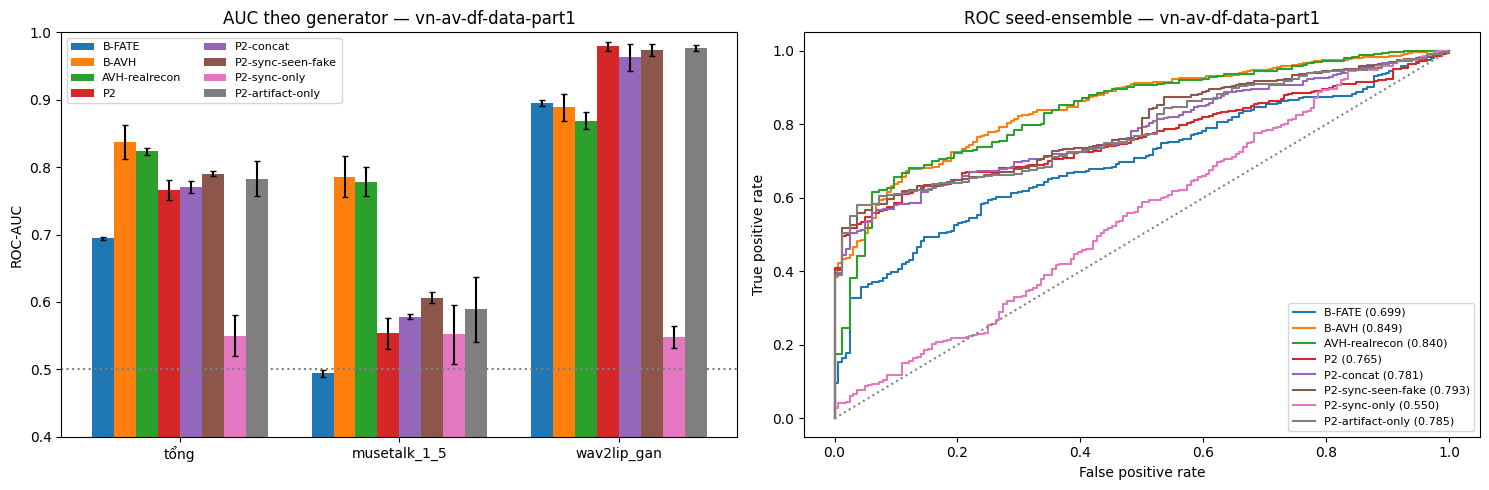

In [ ]:
for name, part in groups.items():
    generators = ["tổng", *sorted(set(gens[part]) - {"-"})]
    fig, (left, right) = plt.subplots(1, 2, figsize=(15, 5))
    width = 0.8 / len(archs)
    for i, a in enumerate(archs):
        run = [k for k in models if k[0] == a]
        values = [[auc(part if g == "tổng" else part & ((labels == 0) | (gens == g)), scores(*k)) for k in run]
                  for g in generators]
        left.bar(np.arange(len(generators)) + i * width, [np.mean(v) for v in values], width,
                 yerr=[np.std(v, ddof=1) if len(v) > 1 else 0 for v in values], label=label(a), capsize=2)
        sel = part & np.isfinite(ensemble(a))
        fpr, tpr, _ = roc_curve(labels[sel], ensemble(a)[sel])
        right.plot(fpr, tpr, label=f"{label(a)} ({auc(part, ensemble(a)):.3f})")
    left.set_xticks(np.arange(len(generators)) + 0.4 - width / 2, generators)
    left.axhline(0.5, color="gray", linestyle=":")
    left.set(ylim=(0.4, 1.0), ylabel="ROC-AUC", title=f"AUC theo generator - {name}")
    left.legend(fontsize=8, ncol=2)
    right.plot([0, 1], [0, 1], color="gray", linestyle=":")
    right.set(xlabel="False positive rate", ylabel="True positive rate", title=f"ROC seed-ensemble - {name}")
    right.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(OUTPUT / f"{SPLIT}_{name.replace(' ', '_')}.png", dpi=120)
    plt.show()

## 7. Chi phí và dự tính GPU
Thời gian đo thật: train (`resources.json`), trích feature (`extraction.json`), sinh (`generation.json` → `sessions`, có từ khi ghi log phiên).
Dự tính cho part mới tỉ lệ theo số mẫu; Kaggle: 30 giờ GPU/tuần, tối đa 12 giờ/phiên, 2×T4.

In [7]:
rows = []
for a in archs:
    run = [models[k]["resources"] for k in models if k[0] == a]
    rows.append([label(a), f"{run[0]['trainable_parameters']:,}", ms([r["elapsed_this_session_s"] / 60 for r in run], 1),
                 ms([r["peak_gpu_bytes"] / 2**20 for r in run], 0)])
display(Markdown(table(["Model", "Tham số train", "Train/seed (phút)", "Peak GPU (MB)"], rows)))
samples = selection["samples"]
per_sample = {}
for folder in map(Path, CACHES):
    for info in sorted(folder.glob("*/extraction.json")):
        data = read(info)
        per_sample[info.parent.name] = data["elapsed_s"] / data["samples"]
        print(f"Trích {info.parent.name}: {data['samples']} mẫu, {data['elapsed_s'] / 3600:.2f} h trên {data.get('devices')}")
for folder in map(Path, GENERATED):
    if (folder / "generation.json").exists():
        for s in read(folder / "generation.json").get("sessions", []):
            print(f"Sinh {folder.name} {s['generators']}: {s['pairs_done']} cặp, {s['elapsed_s'] / 3600:.2f} h, "
                  f"{s['gpus']} GPU, giây/cặp {s['seconds_per_pair']}")
train_h = sum(models[k]["resources"]["elapsed_this_session_s"] for k in models) / 3600
NEW_SAMPLES = samples  # Đổi để dự tính cho part mới (số mẫu sau generate).
scale = NEW_SAMPLES / samples
print(f"\nDự tính cho {NEW_SAMPLES} mẫu: trích " +
      ", ".join(f"{k} {v * NEW_SAMPLES / 3600:.1f} h" for k, v in per_sample.items()) +
      f"; train {len(models)} model {train_h * scale:.1f} h (GPU, cùng cấu hình 2×T4).")

| Model | Tham số train | Train/seed (phút) | Peak GPU (MB) |
|---|---|---|---|
| B-FATE | 2,592,385 | 11.2 ± 3.3 | 70 ± 0 |
| B-AVH | 344,961 | 3.5 ± 1.0 | 24 ± 0 |
| AVH-realrecon | 362,947 | 5.5 ± 1.6 | 35 ± 0 |
| P2 | 478,532 | 5.8 ± 1.4 | 38 ± 0 |
| P2-concat | 494,850 | 8.5 ± 2.8 | 38 ± 0 |
| P2-sync-seen-fake | 726,213 | 8.5 ± 2.0 | 40 ± 0 |
| P2-sync-only | 116,225 | 7.0 ± 2.4 | 37 ± 0 |
| P2-artifact-only | 461,954 | 5.6 ± 0.6 | 33 ± 0 |

Trích avhubert: 2954 mẫu, 4.73 h trên ['cuda:0', 'cuda:0', 'cuda:1', 'cuda:1']
Trích dinov2: 2954 mẫu, 0.40 h trên ['cuda:0', 'cuda:1']
Trích fate: 2954 mẫu, 5.57 h trên ['cuda:0', 'cuda:1']

Dự tính cho 2954 mẫu: trích avhubert 4.7 h, dinov2 0.4 h, fate 5.6 h; train 24 model 2.8 h (GPU, cùng cấu hình 2×T4).
